# Plotting the baseline, the late bubbles and the 3 bubble sequence.

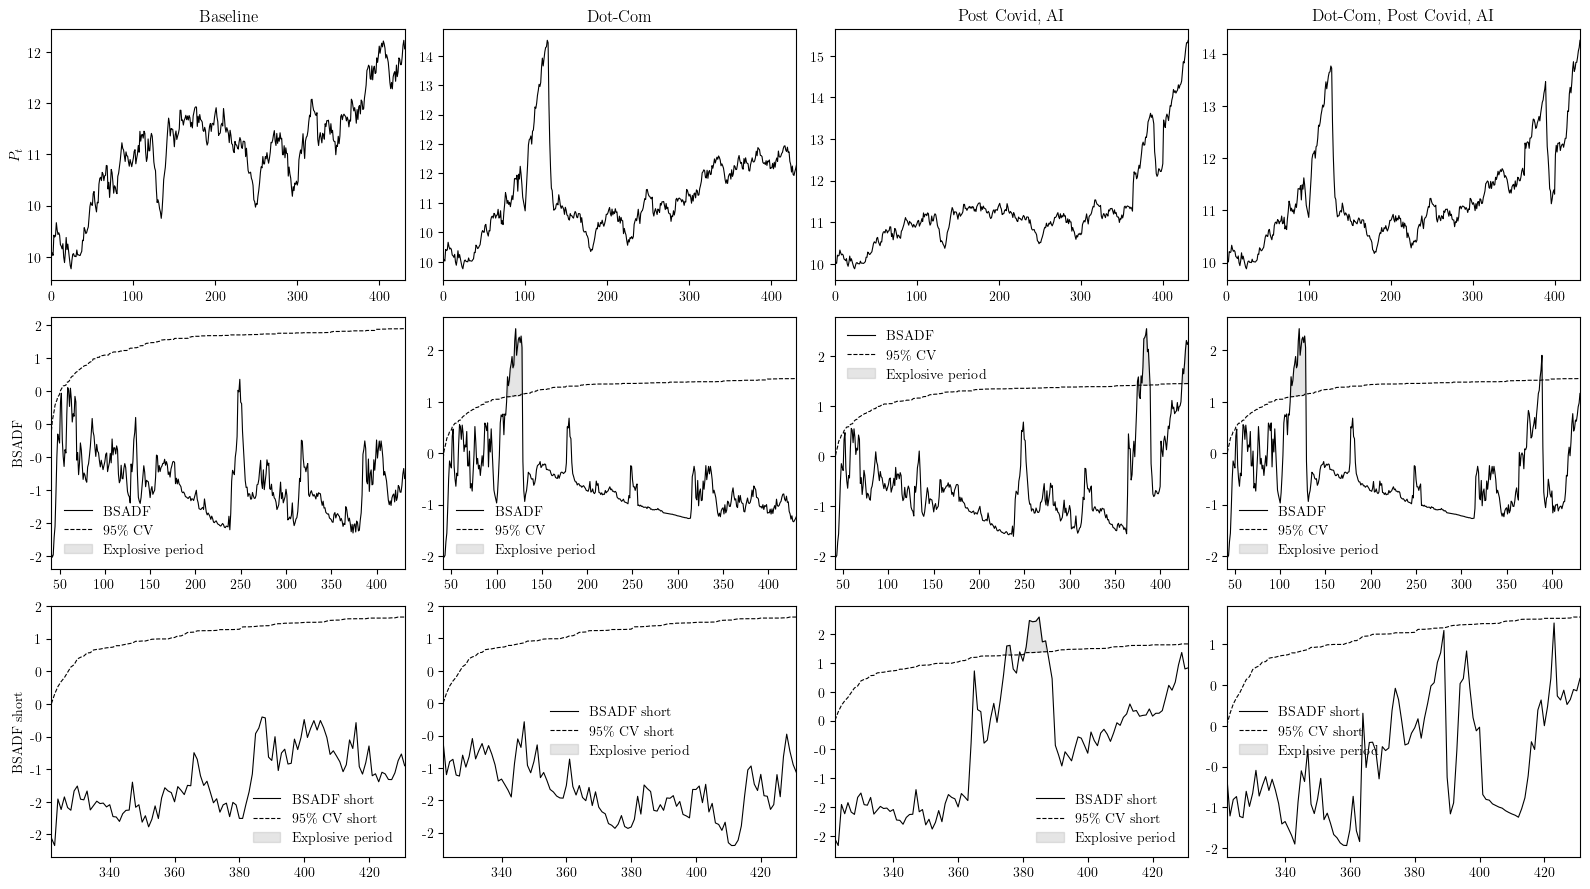

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ---------------- Plot settings ----------------
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# ---------------- Paths ----------------
data_dir = Path("data") if Path("data").exists() else Path("simulation/data")
results_dir = Path("results") if Path("results").exists() else Path("simulation/results")

series = [
    ("nobubble", "Baseline"),
    ("dotcom", "Dot-Com"),
    ("latebubbles", "Post Covid, AI"),
    ("3bubbles", "Dot-Com, Post Covid, AI"),
]

fmt_thousands_dot = FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))

def read_num_col(path):
    df = pd.read_csv(path)
    return df.select_dtypes(include="number").iloc[:, 0]

def load_bsadf_cv(prefix, short=False):
    sfx = "_short" if short else ""
    bs_path = results_dir / f"P_{prefix}_bsadf{sfx}.csv"
    cv_path = results_dir / f"P_{prefix}_cv{sfx}.csv"
    if not (bs_path.exists() and cv_path.exists()):
        return None, None
    bs = read_num_col(bs_path)
    cv = pd.read_csv(cv_path)
    cv95_col = next((c for c in cv.columns if "95" in str(c)), cv.columns[1])
    return bs, cv[cv95_col]

fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=False)

for j, (key, title) in enumerate(series):
    # ---------- Row 1: Price ----------
    ax = axes[0, j]
    p = read_num_col(data_dir / f"P_{key}.csv")
    t_price = p.index
    ax.plot(t_price, p.values, color='black', linewidth=0.8, ls='-')
    ax.set_title(title)
    ax.set_xlim(t_price.min(), t_price.max())  # remove empty margins
    if j == 0:
        ax.set_ylabel(r'$P_t$')
    else:
        ax.set_ylabel('')
    ax.yaxis.set_major_formatter(fmt_thousands_dot)

    # ---------- Row 2: BSADF (full) ----------
    ax = axes[1, j]
    bs, cv95 = load_bsadf_cv(key, short=False)
    if bs is not None:
        t = p.index[-len(bs):]  # aligned time index
        ax.plot(t, bs.values, color='black', linewidth=0.8, ls='-', label='BSADF')
        ax.plot(t, cv95.values, color='black', linewidth=0.8, ls='--', label='95\\% CV')

        # Explosive period shading
        ax.fill_between(
            t,
            bs.values,
            cv95.values,
            where=(bs.values > cv95.values),
            color='grey',
            alpha=0.2,
            label='Explosive period'
        )

        ax.set_xlim(t.min(), t.max())  # no empty space at start
        ax.legend(frameon=False, loc='best')
    else:
        ax.text(0.5, 0.5, "Missing BSADF/CV", ha="center", va="center", transform=ax.transAxes)

    if j == 0:
        ax.set_ylabel('BSADF')
    else:
        ax.set_ylabel('')
    ax.yaxis.set_major_formatter(fmt_thousands_dot)

    # ---------- Row 3: BSADF (short) ----------
    ax = axes[2, j]
    bs_s, cv95_s = load_bsadf_cv(key, short=True)
    if bs_s is not None:
        t_short = p.index[-len(bs_s):]  # aligned time index
        ax.plot(t_short, bs_s.values, color='black', linewidth=0.8, ls='-', label='BSADF short')
        ax.plot(t_short, cv95_s.values, color='black', linewidth=0.8, ls='--', label='95\\% CV short')

        # Explosive period shading
        ax.fill_between(
            t_short,
            bs_s.values,
            cv95_s.values,
            where=(bs_s.values > cv95_s.values),
            color='grey',
            alpha=0.2,
            label='Explosive period'
        )

        ax.set_xlim(t_short.min(), t_short.max())  # no empty space at start
        ax.legend(frameon=False, loc='best')
    else:
        ax.text(0.5, 0.5, "Missing short BSADF/CV", ha="center", va="center", transform=ax.transAxes)

    if j == 0:
        ax.set_ylabel('BSADF short')
    else:
        ax.set_ylabel('')
    ax.yaxis.set_major_formatter(fmt_thousands_dot)

plt.tight_layout()
# Optional save:
plt.savefig('plots/simulation_bubbles_12panel.pdf')
plt.show()